# Notebook 13 | Central Limit Theorem

In [1]:
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_mean
from foundations_of_probability_and_statistics.cars.horsepower_moments import conditional_horsepower_variance
from foundations_of_probability_and_statistics.cars.sample_from_car_distribution import sample_from_car_distribution

import pandas as pd

# show all rows of data frames and series per default
pd.set_option("display.max_rows", None)

## The central limit theorem

Fix a brand $b$ and sample $X = (H \mid B = b)$ with mean $\mu_b = \mathbb{E}[H \mid B = b]$ and
variance $\sigma_b^2 = \mathrm{Var}(H \mid B = b)$. For block size $n$, the block means are
approximately normal:

$$\bar{X}_n \overset{\cdot}{\sim} \mathcal{N}\left(\mu_b, \, \frac{\sigma_b^2}{n}\right), \qquad
Z = \frac{\bar{X}_n - \mu_b}{\sigma_b / \sqrt{n}} \overset{\cdot}{\sim} \mathcal{N}(0, 1).$$

## Derivation

1. Fix $X = (H \mid B = \text{VW})$ with $\mu = 150$ and $\sigma = \sqrt{4500} \approx 67.08$.
2. Standardize a block mean: $Z = (\bar{X}_n - \mu) / (\sigma / \sqrt{n})$.
3. The CLT says $Z$ is approximately standard normal for large $n$.
4. With $n = 50$ and $\bar{x} = 160$ this gives $z \approx 1.05$.

## Worked example (by hand)

One worked z-score for $X = (H \mid B = \text{VW})$ with $\mu = 150$, $\sigma = \sqrt{4500} \approx 67.08$,
$n = 50$ and $\bar{x} = 160$:

$$z = \frac{160 - 150}{67.08 / \sqrt{50}} \approx 1.05.$$

In [2]:
import math

# one worked z-score for X = (H | B = VW): mu = 150, sigma = sqrt(4500), n = 50, xbar = 160
mu = conditional_horsepower_mean("VW")
sigma = math.sqrt(conditional_horsepower_variance("VW"))
z = (160 - mu) / (sigma / math.sqrt(50))
assert math.isclose(mu, 150.0)
assert math.isclose(sigma, 67.08, rel_tol=1e-4)
assert math.isclose(z, 1.05, rel_tol=0.01)
z

1.05409255338946

## Generalization

One sample of 500,000 cars: per-brand contiguous blocks of size $n = 50$ give block means histogrammed
against the exact normal $\mathcal{N}(\mu_b, \sigma_b^2 / n)$.

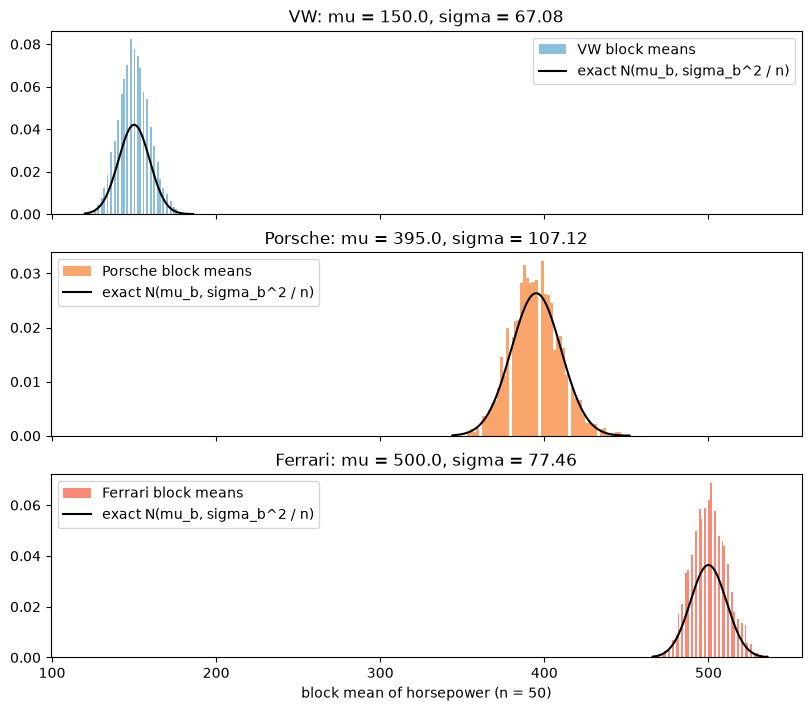

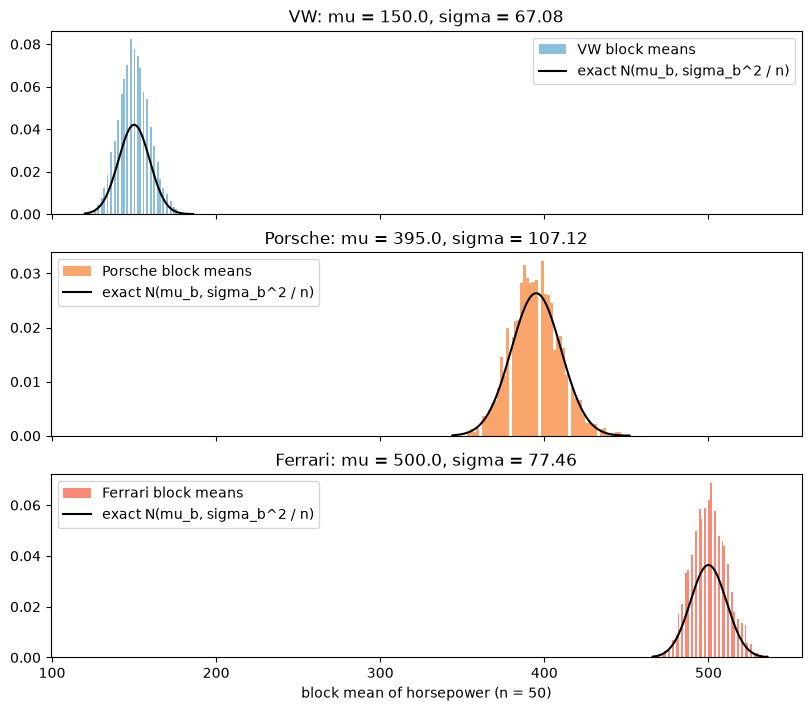

In [3]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

cars = sample_from_car_distribution(n_cars=500_000, random_state=42)

# per-brand contiguous block means of size 50 against N(mu_b, sigma_b^2 / n)
block = 50
figure, axes = plt.subplots(3, 1, figsize=(8.0, 7.0), dpi=100, layout="constrained", sharex=True)
for ax, brand, cmap_name in zip(axes, ["VW", "Porsche", "Ferrari"], ["Blues", "Oranges", "Reds"], strict=True):
    values = cars[cars["brand"] == brand]["horsepower"].to_numpy(dtype=float)
    means = values[: len(values) // block * block].reshape(-1, block).mean(axis=1)
    mu = conditional_horsepower_mean(brand)
    sigma = float(np.sqrt(conditional_horsepower_variance(brand)))
    # standardized block means have mean ~0 and variance ~1 under the CLT
    standardized = (means - mu) / (sigma / np.sqrt(block))
    assert abs(float(standardized.mean())) < 0.05
    assert math.isclose(float(standardized.var(ddof=0)), 1.0, rel_tol=0.05)
    grid = np.linspace(means.min(), means.max(), 200)
    ax.hist(means, bins=60, density=True, color=matplotlib.colormaps[cmap_name](0.55), alpha=0.7, label=f"{brand} block means")
    ax.plot(grid, stats.norm.pdf(grid, loc=mu, scale=sigma / np.sqrt(block)), color="black", label="exact N(mu_b, sigma_b^2 / n)")
    ax.set_title(f"{brand}: mu = {mu:.1f}, sigma = {sigma:.2f}")
    ax.legend()
axes[-1].set_xlabel("block mean of horsepower (n = 50)")
figure

## References

- Blitzstein, J. K., Hwang, J. (2019): "Introduction to Probability", 2nd ed., Chapman & Hall/CRC, chapter "Inequalities and Limit Theorems" (CLT is a named section), https://www.routledge.com/Introduction-to-Probability-Second-Edition/Blitzstein-Hwang/p/book/9781138369917 (free PDF: https://probabilitybook.net/).
- Wasserman, L. (2004): "All of Statistics: A Concise Course in Statistical Inference", Springer Texts in Statistics, chapter "Convergence of Random Variables" (LLN, CLT), https://doi.org/10.1007/978-0-387-21736-9.
- scipy.stats.rv_discrete, https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.rv_discrete.html.